In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sbn
import numpy as np 

import torch

import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import r2_score
from sklearn.metrics import silhouette_score, silhouette_samples
import umap
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

from amlvae.models.VAE import VAE 
from amlvae.train.Trainer import Trainer

from amlvae.data.ExprProcessor import ExprProcessor
from amlvae.data.ClinProcessor import ClinProcessor

from sklearn.model_selection import KFold

from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split

import umap 
from sklearn.decomposition import PCA

# auto reimport 
%load_ext autoreload
%autoreload 2

# VAE + Drug response -> generalization to MDS 

Use beatAML "priorMDS=y" as the drug response test set. 

In [2]:
topk = 2500
max_tstat_val = 0.25

In [3]:
mds_expr = pd.read_csv('../data/20241219_WTS_Data_Proj805.csv', sep='\t').drop(columns=['counts']).rename(columns={'gene_id':'gene_name', 'array_id':'id'}).assign(id_type='array_id')
mds_expr = mds_expr.dropna() 
mds_expr.head() 

,id,gene_name,FPKM,id_type
0,MLL_00003,DDX11L1,0.061998,array_id
1,MLL_00003,WASH7P,2.672530,array_id
3,MLL_00003,MIR6859-2,0.000000,array_id
4,MLL_00003,MIR6859-4,0.000000,array_id
5,MLL_00003,MIR6859-1,0.000000,array_id


In [4]:
aml_expr = pd.read_csv('../data/aml_full_manuscript.csv')[['id', 'gene_name', 'fpkm_unstranded']].rename(columns={'fpkm_unstranded': 'FPKM'}).assign(id_type='gdc_id')
aml_expr = aml_expr.dropna() 
aml_expr = aml_expr.groupby(['id', 'gene_name', 'id_type']).max().reset_index() # use max to resolve duplicates (usually a zero and a non-zero)
aml_expr.head()

,id,gene_name,id_type,FPKM
0,001454b2-aff9-4659-85a6-73fb8092589a,5S_rRNA,gdc_id,1.2517
1,001454b2-aff9-4659-85a6-73fb8092589a,5_8S_rRNA,gdc_id,0.2182
2,001454b2-aff9-4659-85a6-73fb8092589a,7SK,gdc_id,0.0000
3,001454b2-aff9-4659-85a6-73fb8092589a,A1BG,gdc_id,0.1161
4,001454b2-aff9-4659-85a6-73fb8092589a,A1BG-AS1,gdc_id,0.5899


In [5]:
aml_stats = aml_expr.groupby('gene_name')['FPKM'].agg(['mean', 'std']).reset_index()
mds_stats = mds_expr.groupby('gene_name')['FPKM'].agg(['mean', 'std']).reset_index() 
stats = aml_stats.merge(mds_stats, on='gene_name', suffixes=('_aml', '_mds'))
stats = stats.assign(mean_diff=lambda x: x['mean_aml'] - x['mean_mds'],
             std_diff=lambda x: x['std_aml'] - x['std_mds'])
stats = stats.assign(tstat = lambda x: x['mean_diff'] / np.sqrt((x['std_aml']**2 + x['std_mds']**2) / 2))

candidate_genes = stats[lambda x: x.tstat.abs() < max_tstat_val].gene_name.tolist() 

len(candidate_genes)

6730

In [6]:
# find the overlapping gene_names between the two datasets. 
overlap_genes = set(mds_expr['gene_name']).intersection(set(aml_expr['gene_name']))
print(f'Number of overlapping genes: {len(overlap_genes)}')
non_overlap_genes_mds = set(mds_expr['gene_name']).difference(overlap_genes)
non_overlap_genes_aml = set(aml_expr['gene_name']).difference(overlap_genes)
print(f'Number of non-overlapping genes in AML: {len(non_overlap_genes_aml)}')
print(f'Number of non-overlapping genes in MDS: {len(non_overlap_genes_mds)}')

Number of overlapping genes: 23220
Number of non-overlapping genes in AML: 36207
Number of non-overlapping genes in MDS: 3008


In [7]:
mds_expr = mds_expr[lambda x: x['gene_name'].isin(overlap_genes) & x['gene_name'].isin(candidate_genes)]
aml_expr = aml_expr[lambda x: x['gene_name'].isin(overlap_genes) & x['gene_name'].isin(candidate_genes)]

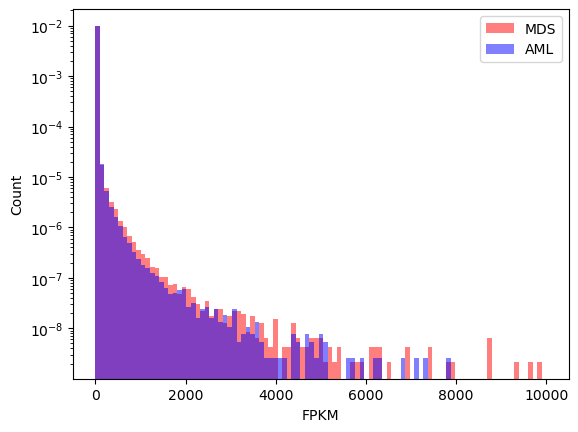

In [8]:
plt.figure() 
plt.hist(mds_expr['FPKM'], bins=np.linspace(0, 10000, 100), alpha=0.5, label='MDS', color='r', density=True)
plt.hist(aml_expr['FPKM'], bins=np.linspace(0, 10000, 100), alpha=0.5, label='AML', color='b', density=True)
plt.xlabel('FPKM')
plt.ylabel('Count')
plt.legend()
plt.yscale('log')
plt.show() 

In [9]:

stats = stats[lambda x: x.gene_name.isin(candidate_genes) & x.gene_name.isin(overlap_genes)]
mds_topk_genes = stats.sort_values('std_mds', ascending=False).head(topk).gene_name.tolist()
aml_topk_genes = stats.sort_values('std_aml', ascending=False).head(topk).gene_name.tolist() 

topk_genes = np.sort(list(set(mds_topk_genes).intersection(set(aml_topk_genes)) )).tolist()
len(topk_genes)

2042

In [10]:
mds_expr = mds_expr[lambda x: x['gene_name'].isin(topk_genes)]
aml_expr = aml_expr[lambda x: x['gene_name'].isin(topk_genes)] 

In [11]:
# convert to log(FPKM + 1)
mds_expr = mds_expr.assign(log_FPKM=lambda x: np.log2(x['FPKM'] + 1))
aml_expr = aml_expr.assign(log_FPKM=lambda x: np.log2(x['FPKM'] + 1)) 

In [12]:
# zscore 
# NOTE: we zscore both datasets with the MDS stats 
log_stats_mds = mds_expr.groupby('gene_name')['log_FPKM'].agg(['mean', 'std']).reset_index()  

In [13]:
mds_expr = mds_expr.merge(log_stats_mds, on='gene_name') 
aml_expr = aml_expr.merge(log_stats_mds, on='gene_name') 

In [14]:
mds_expr = mds_expr.assign(zscore_FPKM=lambda x: (x['log_FPKM'] - x['mean']) / x['std'])
aml_expr = aml_expr.assign(zscore_FPKM=lambda x: (x['log_FPKM'] - x['mean']) / x['std'])

In [15]:
mds_expr = mds_expr.rename(columns={'gene_id':'gene_name', 'array_id':'id'})

In [16]:
# convert to wide format
mds_expr_wide = mds_expr.pivot(index='id', columns='gene_name', values='zscore_FPKM')
aml_expr_wide = aml_expr.pivot(index='id', columns='gene_name', values='zscore_FPKM')

In [17]:
aml_expr_wide = aml_expr_wide.fillna(0)
mds_expr_wide = mds_expr_wide.fillna(0) 

X_aml = aml_expr_wide[topk_genes].values
X_mds = mds_expr_wide[topk_genes].values 

aml_ids = aml_expr_wide.index.tolist()
mds_ids = mds_expr_wide.index.tolist() 

In [18]:
X = np.concatenate([X_aml, X_mds], axis=0)
ids = aml_ids + mds_ids 

In [19]:
aml_clin = pd.read_csv('../data/beataml_clinical_for_inputs.csv')
priorMDS_ids = aml_clin[lambda x: x.priorMDS == 'y'].gdc_id.unique()

In [20]:
test_ixs = [i for i, id_ in enumerate(ids) if id_ in priorMDS_ids]
test_ids = [ids[i] for i in test_ixs] 
assert len(set(test_ids) - set(priorMDS_ids)) == 0, "Test IDs should be a subset of priorMDS_ids"
x_test = X[test_ixs]

candidate_ids = [i for i in ids if i not in priorMDS_ids] 
train_ids, val_ids = train_test_split(candidate_ids, test_size=0.15, random_state=42)

train_ixs = [i for i, id_ in enumerate(ids) if id_ in train_ids]
x_train = X[train_ixs]
train_ids = [ids[i] for i in train_ixs]

val_ixs = [i for i, id_ in enumerate(ids) if id_ in val_ids]
x_val = X[val_ixs]
val_ids = [ids[i] for i in val_ixs]

assert len(set(train_ids) & set(val_ids)) == 0, "Train and validation IDs should not overlap"

print(f'Train set size: {x_train.shape}')
print(f'Test set size: {x_test.shape}')
print(f'Val set size: {x_val.shape}')

Train set size: (1014, 2042)
Test set size: (49, 2042)
Val set size: (180, 2042)


In [21]:

train_df = pd.DataFrame(x_train, index=train_ids, columns=topk_genes)
val_df = pd.DataFrame(x_val, index=val_ids, columns=topk_genes)
test_df = pd.DataFrame(x_test, index=test_ids, columns=topk_genes) 

out = './data/'

train_df.to_csv(f'{out}/amlmds_train.csv', index=True)
val_df.to_csv(f'{out}/amlmds_val.csv', index=True)    
test_df.to_csv(f'{out}/amlmds_test.csv', index=True)    
